In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
train = pd.read_csv('/content/gdrive/MyDrive/PRML_LAB/Assignment3/train_knn.txt',sep=",",header=None)
test = pd.read_csv('/content/gdrive/MyDrive/PRML_LAB/Assignment3/test_knn.txt',sep=",",header=None)

print(train)
print(test)

    0  1  2
0   7  7  1
1   7  4  1
2   6  4  1
3   7  5  1
4   7  6  1
5   6  7  1
6   6  6  1
7   3  4  2
8   2  3  2
9   3  2  2
10  4  3  2
11  3  3  2
12  4  4  2
13  1  4  2
   0  1
0  3  7
1  7  7
2  4  3
3  2  8
4  3  5
5  1  2
6  4  8
7  8  3
8  8  4


In [ ]:
class_1 = train[train[2]==1]
class_1

,0,1,2
0,7,7,1
1,7,4,1
2,6,4,1
3,7,5,1
4,7,6,1
5,6,7,1
6,6,6,1


In [ ]:
class_2 = train[train[2]==2]
class_2

,0,1,2
7,3,4,2
8,2,3,2
9,3,2,2
10,4,3,2
11,3,3,2
12,4,4,2
13,1,4,2


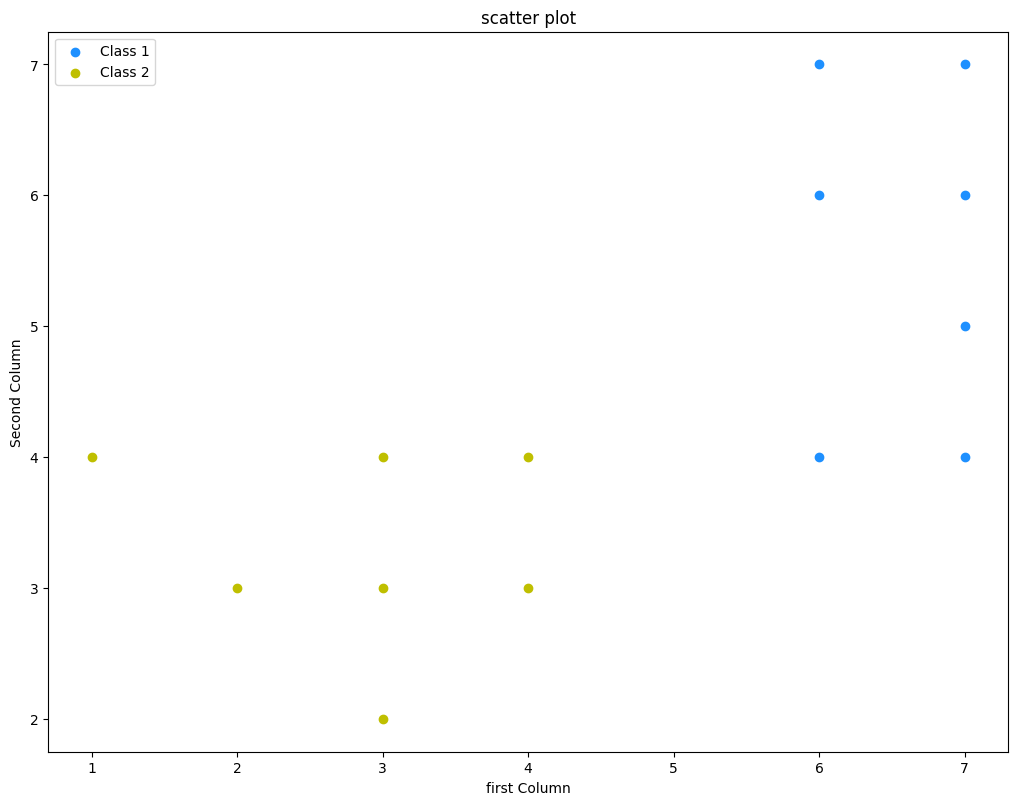

In [ ]:
fig=plt.figure()
ax=fig.add_axes([0,0,1.5,1.5])
ax.scatter(class_1[0], class_1[1], color='dodgerblue', label="Class 1")
ax.scatter(class_2[0], class_2[1] , color='y', label="Class 2")
ax.set_xlabel('first Column')
ax.set_ylabel('Second Column')
ax.set_title('scatter plot')
plt.legend(loc="upper left")
plt.show()

In [ ]:
def bubbleSort(array, target_label):
    for i in range(len(array)):
        for j in range(0, len(array) - i - 1):
            if array[j] > array[j + 1]:
                temp = array[j]
                array[j] = array[j+1]
                array[j+1] = temp

                temp = target_label[j]
                target_label[j] = target_label[j+1]
                target_label[j+1] = temp
    return array

In [ ]:
def calculate_dist(x,y):
    global train
    dist = []
    target_label = list(train[2])
    for i,j in zip(train[0], train[1]):
        dist.append(((i-x)**2 +(j-y)**2))
    dist = bubbleSort(dist,target_label)
    return dist,target_label

In [ ]:
distances = []
target_labels = []
for i,j in zip(test[0], test[1]):
    a, b = calculate_dist(i,j)
    distances.append(a)
    target_labels.append(b)

In [ ]:
distances = np.array(distances)
distances.shape

(9, 14)

In [ ]:
target_labels = np.array(target_labels)
target_labels.shape

(9, 14)

In [ ]:
k=input ("Enter value of k :")
k=int(k)
type(k)

Enter value of k :3


int

In [ ]:
output = []
predicted_class_1 = []
predicted_class_2 = []
prediction_text = []

for i in range(len(test)):
    count_1, count_2 = 0, 0

    point = test.iloc[i].values   # get row as numpy array
    print('Test Point: ', point)
    s = 'Test Point: ' + str(point) + '\n'
    prediction_text.append(s)

    for j in range(k):
        print('Distance : ', distances[i][j], 'Class : ', target_labels[i][j])
        s = 'Distance : ' + str(distances[i][j]) + '   Class : ' + str(target_labels[i][j]) + '\n'
        prediction_text.append(s)
        if target_labels[i][j] == 1:
            count_1 += 1
        else:
            count_2 += 1

    if count_1 > count_2:
        print('Predicted Class 1\n')
        prediction_text.append('Predicted Class 1\n\n')
        predicted_class_1.append(list(point))
    else:
        print('Predicted Class 2\n')
        prediction_text.append('Predicted Class 2\n\n')
        predicted_class_2.append(list(point))


Test Point:  [3 7]
Distance :  9 Class :  1
Distance :  9 Class :  2
Distance :  10 Class :  1
Predicted Class 1

Test Point:  [7 7]
Distance :  0 Class :  1
Distance :  1 Class :  1
Distance :  1 Class :  1
Predicted Class 1

Test Point:  [4 3]
Distance :  0 Class :  2
Distance :  1 Class :  2
Distance :  1 Class :  2
Predicted Class 2

Test Point:  [2 8]
Distance :  17 Class :  1
Distance :  17 Class :  2
Distance :  17 Class :  2
Predicted Class 2

Test Point:  [3 5]
Distance :  1 Class :  2
Distance :  2 Class :  2
Distance :  4 Class :  2
Predicted Class 2

Test Point:  [1 2]
Distance :  2 Class :  2
Distance :  4 Class :  2
Distance :  4 Class :  2
Predicted Class 2

Test Point:  [4 8]
Distance :  5 Class :  1
Distance :  8 Class :  1
Distance :  10 Class :  1
Predicted Class 1

Test Point:  [8 3]
Distance :  2 Class :  1
Distance :  5 Class :  1
Distance :  5 Class :  1
Predicted Class 1

Test Point:  [8 4]
Distance :  1 Class :  1
Distance :  2 Class :  1
Distance :  4 Class : 

In [ ]:
with open('prediction.txt', 'w') as writefile:
    for line in prediction_text:
        writefile.write(line)

In [ ]:
df1 = pd.DataFrame(predicted_class_1, columns = [0,1])
df2 = pd.DataFrame(predicted_class_2, columns = [0,1])

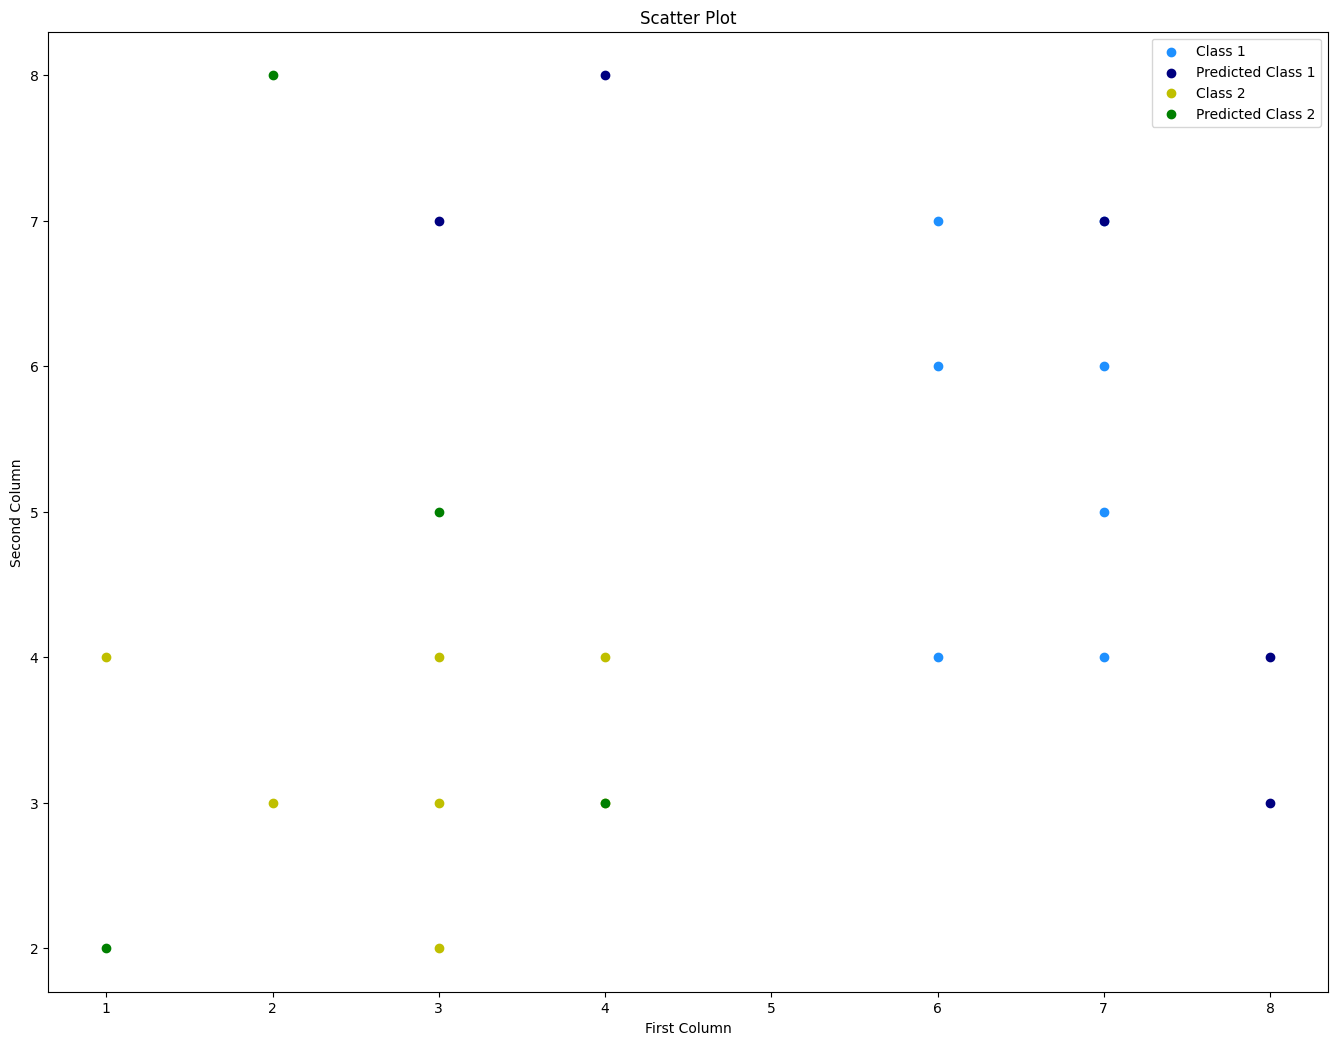

In [ ]:
fig=plt.figure()
ax=fig.add_axes([0,0,2,2])
ax.scatter(class_1[0], class_1[1], color='dodgerblue', label="Class 1")
ax.scatter(df1[0], df1[1], color='navy', label="Predicted Class 1")
ax.scatter(class_2[0], class_2[1] , color='y', label="Class 2")
ax.scatter(df2[0], df2[1] , color='g', label="Predicted Class 2")
ax.set_xlabel('First Column')
ax.set_ylabel('Second Column')
ax.set_title('Scatter Plot')
plt.legend(loc="upper right")
plt.show()